# 3. Routing

![Router](docs/router.png)

In [1]:
from langchain.agents import create_agent
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from typing import Literal
from langchain_core.tools import tool

Define the model

In [2]:
llm = AzureChatOpenAI(model="gpt-4.1-mini")

Define the tool/action the LLM will have access to

In [3]:
@tool
def weather_tool(location: Literal["Chicago", "New York", "Los Angeles"]) -> str:
    """
    Get the current weather for a specified location.
    Args:
        location (str): The name of the city to get the weather for.
                        Must be one of "Chicago", "New York", or "Los Angeles".
    Returns:
        str: A string describing the current weather in the specified location.
    """

    weather_data = {
        "New York": "Sunny, 25°C",
        "Los Angeles": "Cloudy, 22°C",
        "Chicago": "Rainy, 18°C",
    }
    return weather_data.get(location, "Weather data not available for this location.")

Create a simple weather agent

In [4]:
weather_agent = create_agent(model=llm, tools=[weather_tool])

Define the router

The router is a specific node in the graph, that will categorize the incoming message.

Notice the usages of a structured output, that way we are binding the router to only make use of the given outputs

In [5]:
from pydantic import BaseModel


class RouterOutput(BaseModel):
    """Output of the router, indicating which agent to use. Set to 'unknown' if no agent is applicable.
    Options:
     - travel_advisor: If user is requesting travel advice.
     - weather: If user is requesting weather information.
     - unknown: If you are not sure what agent to use.
    """

    agent: Literal["travel_advisor", "unknown", "weather"]

In [6]:
def router(state) -> Literal["travel_advisor", "unknown", "weather"]:
    structured_llm = llm.with_structured_output(RouterOutput)
    response = structured_llm.invoke(input=state["messages"])
    print(f"Router response: {response}")
    return response.agent

Travel Advisor is a different node, but since it calls an llm, you could call it a agent as well

In [7]:
def travel_advisor(state) -> str:
    print("Node: Travel Advisor")
    msgs = [
        SystemMessage(
            "You are a travel expert. Based on the user's input, suggest 1 travel destination."
        ),
        state["messages"][-1],
    ]
    response = llm.invoke(msgs)

    return {"messages": [response]}

Finally our unknown node that is executed when the router has no idea what the category should be

In [8]:
def unknown_node(state):
    print("Node: Unknown")
    return {
        "messages": [
            AIMessage(
                content="I can not assist with that request. "
                "Could you please rephrase or ask something else? "
                "I can help you with travel advice or weather information."
            )
        ]
    }

Setting up a langgraph graph

Linking all the nodes together and creating a workflow

In [9]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

builder = StateGraph(MessagesState)

builder.add_node("travel_advisor", travel_advisor)
builder.add_node("unknown", unknown_node)
builder.add_node("weather", weather_agent)

builder.add_conditional_edges(START, router)
builder.add_edge("travel_advisor", END)
builder.add_edge("unknown", END)
builder.add_edge("weather", END)

graph = builder.compile()

Printing out the workflow diagram

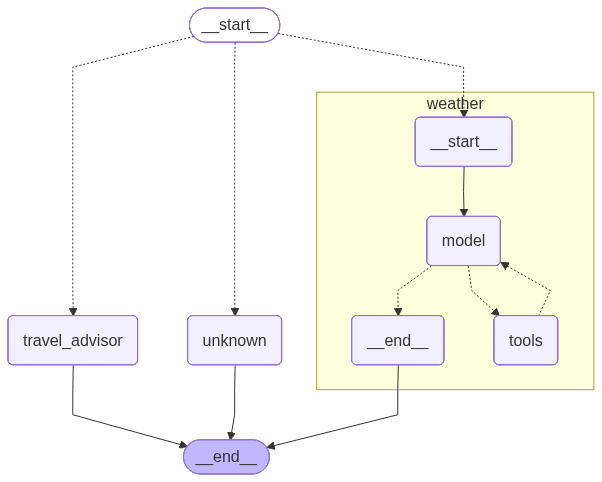

In [10]:
from IPython.display import Image

Image(graph.get_graph(xray=1).draw_mermaid_png())

Executing the router workflow

In [11]:
messages = [HumanMessage(content="who is sammy deprez")]

for msg in messages:
    msg.pretty_print()

async for event in graph.astream(input={"messages": messages}, stream_mode="updates"):
    for node in graph.nodes.keys():
        node_output = event.get(node, {})
        if node_output is not None:
            output_msgs = node_output.get("messages", [])
            for msg in output_msgs:
                msg.pretty_print()

================================ Human Message =================================

who is sammy deprez
Router response: agent='unknown'
Node: Unknown
================================== Ai Message ==================================

I can not assist with that request. Could you please rephrase or ask something else? I can help you with travel advice or weather information.
